# WebNLG IR Results Plotting Notebook

This notebook loads the evaluation summary files and produces paper-ready plots for:

1. Representation comparison for one complexity setting.
2. Complexity comparison across `min2`, `min3`, and `min4`.
3. Language-direction breakdowns.
4. Method × representation heatmaps.
5. Question-type breakdowns.
6. Hybrid gain over the best single representation.

In [ ]:
# =========================
# Configuration
# =========================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = Path("paper_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Main metric to plot. Change to "Recall@10", "MRR@10", "nDCG@100", etc. if needed.
METRIC = "nDCG@10"

# Use the same aggregation level everywhere.
#   "directional" = recompute from en_to_en, en_to_es, es_to_en, es_to_es rows.
#   "overall"     = use the evaluator's already-aggregated query_lang=ALL/doc_lang=ALL/scenario=ALL row.
# For the plots comparing language directions, "directional" is required.
AGG_LEVEL = "directional"

# Select one complexity setting for the individual plots.
SELECTED_COMPLEXITY = "min2"

SUMMARY_FILES = {
    "min2": "eval_min2_mixed_normtext/summary_metrics.csv",
    "min3": "eval_min3_mixed_normtext/summary_metrics.csv",
    "min4": "eval_min4_mixed_normtext/summary_metrics.csv",
}

SUMMARY_CSV = SUMMARY_FILES[SELECTED_COMPLEXITY]

DIRECTION_SCENARIOS = {
    "en_to_en": ("en", "en"),
    "en_to_es": ("en", "es"),
    "en_to_mix": ("en", "mix"),
    "ca_to_en": ("ca", "en"),
    "ca_to_es": ("ca", "es"),
    "ca_to_mix": ("ca", "mix"),
    "es_to_en": ("es", "en"),
    "es_to_es": ("es", "es"),
    "es_to_mix": ("es", "mix")
}

DIRECTION_ORDER = ["en→en", "en→es", "en→mix", "ca→en", "ca→es", "ca→mix", "es→en", "es→es", "es→mix"]
COMPLEXITY_ORDER = ["min2", "min3","min4"]

REP_ORDER = [
    "triples",
    "text",
    "concat",
    "hybrid_rrf",
    "hybrid_score",
]

QUESTION_ORDER = ["yes", "no", "extractive"]

print("Metric:", METRIC)
print("Aggregation level:", AGG_LEVEL)
print("Selected complexity:", SELECTED_COMPLEXITY)
print("Selected summary:", SUMMARY_CSV)


Metric: nDCG@10
Aggregation level: directional
Selected complexity: min2
Selected summary: eval_min2_mixed_normtext/summary_metrics.csv


## Shared loading, filtering, and aggregation helpers

Use these functions for every plot. This prevents the individual plot and the min2/min3/min4 comparison from computing different values.

In [2]:
# =========================
# Robust summary loading
# =========================

def read_summary_csv(path, method_mapping=None, strict_method_mapping=False):
    """
    Robust reader for either:
      - comma-separated CSV with dot decimals
      - semicolon-separated CSV with comma decimals

    Parameters
    ----------
    method_mapping : dict, optional
        Mapping from existing method names to new method names, e.g.
        {
            "bm25": "BM25",
            "dense": "Dense retrieval",
            "hybrid_rrf": "Hybrid RRF",
        }

    strict_method_mapping : bool
        If True, raise an error when a mapping key is not found in the file.
    """
    path = str(path)

    with open(path, "r", encoding="utf-8") as f:
        first_line = f.readline()

    if first_line.count(";") > first_line.count(","):
        df = pd.read_csv(path, sep=";", decimal=",", skipinitialspace=True)
    else:
        df = pd.read_csv(path)

    df.columns = [c.strip() for c in df.columns]

    rename_candidates = {
        "question_t": "question_type",
        "question_type3": "question_type",
        "question_type_3way": "question_type",
        "represent": "representation",
        "repr": "representation",
    }

    for old, new in rename_candidates.items():
        if old in df.columns:
            df = df.rename(columns={old: new})

    # Strip whitespace from string/object columns.
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()

    # Rename method values using the provided mapping.
    if method_mapping is not None:
        if "method" not in df.columns:
            raise ValueError(
                f"{path} is missing required column: 'method'\n"
                f"Available columns: {list(df.columns)}"
            )

        if strict_method_mapping:
            existing_methods = set(df["method"].dropna().unique())
            missing_methods = sorted(set(method_mapping.keys()) - existing_methods)

            if missing_methods:
                raise ValueError(
                    "These method_mapping keys were not found in the file: "
                    f"{missing_methods}\n"
                    f"Existing methods: {sorted(existing_methods)}"
                )

        df["method"] = df["method"].replace(method_mapping)

    # Normalize numeric columns.
    string_cols = {
        "method", "representation", "query_lang", "doc_lang",
        "scenario", "split", "question_type"
    }

    for col in df.columns:
        if col not in string_cols:
            if df[col].dtype == "object":
                df[col] = df[col].str.replace(",", ".", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce")

    required = [
        "method", "representation", "query_lang", "doc_lang",
        "scenario", "split", "question_type", "n_queries", METRIC
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path} is missing required columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    return df


def normalize_representation(x):
    x0 = str(x).lower()

    if x0 in {"triples", "triple", "tripleset", "kg"}:
        return "triples"
    if x0 in {"text", "texts", "lex", "lexicalisation", "lexicalization"}:
        return "text"
    if "concat" in x0:
        return "concat"
    if "union" in x0:
        return "hybrid_union_candidates"
    if "rrf" in x0:
        return "hybrid_rrf"
    if "score" in x0:
        return "hybrid_score"
    if "cascade" in x0 or "rerank" in x0:
        return "hybrid_cascade"

    return str(x)


def select_evaluation_level(
    df,
    split="ALL",
    question_type="ALL",
    level="directional",
):
    """
    Select one and only one aggregation level.

    level="directional":
      Uses only concrete direction rows:
        en_to_en, en_to_es, es_to_en, es_to_es
      This is best for recomputing overall means from language directions.

    level="overall":
      Uses only the already-aggregated ALL row:
        query_lang=ALL, doc_lang=ALL, scenario=ALL
      This matches the evaluator's precomputed overall rows.

    Do not mix these two levels in the same figure.
    """
    out = df.copy()

    out = out[out["split"].str.lower() == str(split).lower()].copy()

    if question_type is not None:
        out = out[out["question_type"].str.lower() == str(question_type).lower()].copy()

    if level == "overall":
        out = out[
            (out["query_lang"].astype(str).str.upper() == "ALL") &
            (out["doc_lang"].astype(str).str.upper() == "ALL") &
            (out["scenario"].astype(str).str.upper() == "ALL")
        ].copy()

    elif level == "directional":
        out = out[out["scenario"].isin(DIRECTION_SCENARIOS.keys())].copy()

        # Safety: require scenario to agree with query_lang/doc_lang.
        expected_scenario = out["query_lang"].astype(str) + "_to_" + out["doc_lang"].astype(str)
        out = out[out["scenario"] == expected_scenario].copy()

    else:
        raise ValueError("level must be either 'directional' or 'overall'.")

    out["representation_clean"] = out["representation"].apply(normalize_representation)

    return out


def weighted_mean(group, metric=METRIC, weight_col="n_queries"):
    x = group[metric].astype(float)
    w = group[weight_col].astype(float)

    mask = x.notna() & w.notna() & (w > 0)

    if mask.sum() == 0:
        return np.nan

    return np.average(x[mask], weights=w[mask])


def aggregate(df, group_cols, metric=METRIC):
    rows = []

    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        row["n_queries"] = g["n_queries"].sum()
        row[metric] = weighted_mean(g, metric=metric)
        rows.append(row)

    return pd.DataFrame(rows)


def representation_table_from_summary(path, level=AGG_LEVEL):
    df = read_summary_csv(path)
    selected = select_evaluation_level(
        df,
        split="ALL",
        question_type="ALL",
        level=level,
    )

    table = aggregate(
        selected,
        group_cols=["representation_clean"],
        metric=METRIC,
    )

    table = table[table["representation_clean"].isin(REP_ORDER)].copy()
    table["representation_clean"] = pd.Categorical(
        table["representation_clean"],
        categories=REP_ORDER,
        ordered=True,
    )

    return table.sort_values("representation_clean").reset_index(drop=True)


def load_all_complexities(summary_files=SUMMARY_FILES):
    frames = []
    for complexity, path in summary_files.items():
        d = read_summary_csv(path)
        d["complexity"] = complexity
        d["representation_clean"] = d["representation"].apply(normalize_representation)
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def order_existing(values, preferred_order):
    values = list(pd.Series(values).dropna().unique())
    preferred_present = [x for x in preferred_order if x in values]
    remaining = sorted([x for x in values if x not in preferred_present])
    return preferred_present + remaining


# =========================
# Plot styling helpers
# =========================

def add_bar_labels(ax, fmt="{:.3f}", padding=0.003, fontsize=8, rotation=0):
    for patch in ax.patches:
        height = patch.get_height()

        if pd.isna(height):
            continue

        x = patch.get_x() + patch.get_width() / 2

        ax.text(
            x,
            height + padding,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=rotation,
        )


def style_metric_axis(ax, metric_name, ylim_pad=0.08):
    ax.set_ylabel(metric_name)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    ymin, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(0, ymax * (1 + ylim_pad))


def add_delta_from_best(ax, values, fmt="{:+.3f}", padding=0.014, fontsize=8):
    values = np.asarray(values, dtype=float)
    best = np.nanmax(values)

    for patch, value in zip(ax.patches, values):
        if pd.isna(value):
            continue

        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()

        ax.text(
            x,
            y + padding,
            fmt.format(value - best),
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


## Load and inspect one summary

In [3]:
METHOD_MAPPING = {
    "bm25": "BM25",
    "bge_m3_dense": "BGE_Dense",
    "bge_m3_multivector": "BGE_MV",
    "milco_sparse": "MILCO",
}

df_single = read_summary_csv(
    SUMMARY_CSV,
    method_mapping=METHOD_MAPPING,
    strict_method_mapping=True,
)

print("Rows:", len(df_single))
print("Columns:", list(df_single.columns))
print("Splits:", sorted(df_single["split"].unique()))
print("Question types:", sorted(df_single["question_type"].unique()))
print("Scenarios:", sorted(df_single["scenario"].unique())[:20])
print("Representations:", sorted(df_single["representation"].unique()))
print("Methods:", sorted(df_single["method"].unique()))

display(df_single.head())


Rows: 16448
Columns: ['method', 'representation', 'query_lang', 'doc_lang', 'scenario', 'split', 'question_type', 'n_queries', 'n_relevant', 'AP', 'Recall@5', 'P@5', 'nDCG@5', 'MRR@5', 'Recall@10', 'P@10', 'nDCG@10', 'MRR@10']
Splits: ['ALL', 'dev', 'test', 'train']
Question types: ['ALL', 'extractive', 'no', 'yes']
Scenarios: ['ALL', 'ca_to_en', 'ca_to_es', 'ca_to_mix', 'en_to_en', 'en_to_es', 'en_to_mix', 'es_to_en', 'es_to_es', 'es_to_mix']
Representations: ['concat', 'hybrid_rrf', 'hybrid_score', 'hybrid_union_candidates', 'text', 'triples']
Methods: ['BGE_Dense', 'BGE_MV', 'BM25', 'MILCO']


,method,representation,query_lang,doc_lang,scenario,split,question_type,n_queries,n_relevant,AP,Recall@5,P@5,nDCG@5,MRR@5,Recall@10,P@10,nDCG@10,MRR@10
0,BGE_Dense,concat,ALL,ALL,ALL,ALL,ALL,106848,14.150522,0.766311,0.483174,0.676919,0.784521,0.863773,0.665228,0.559972,0.797360,0.867758
1,BGE_Dense,concat,ALL,ALL,ALL,ALL,extractive,52353,14.141826,0.705504,0.441825,0.622131,0.720008,0.812271,0.622929,0.521905,0.738104,0.817984
2,BGE_Dense,concat,ALL,ALL,ALL,ALL,no,27279,14.143187,0.771646,0.483716,0.684783,0.791395,0.866488,0.665309,0.566003,0.802145,0.870332
3,BGE_Dense,concat,ALL,ALL,ALL,ALL,yes,27216,14.174603,0.877932,0.562171,0.774427,0.901731,0.960120,0.746515,0.627153,0.906548,0.960923
4,BGE_Dense,concat,ALL,ALL,ALL,dev,ALL,6300,14.897143,0.774688,0.453797,0.699556,0.786667,0.857926,0.646069,0.593270,0.799517,0.862615


## Plot 1 — Individual representation comparison

This uses exactly the same function later used in the min2/min3/min4 comparison. If `SELECTED_COMPLEXITY='min4'`, this is the min4 row that must match the comparison plot.

,representation_clean,n_queries,nDCG@10
0,triples,427392,0.710371
1,text,284928,0.659680
2,concat,534240,0.776477
3,hybrid_rrf,427392,0.707667
4,hybrid_score,427392,0.715771


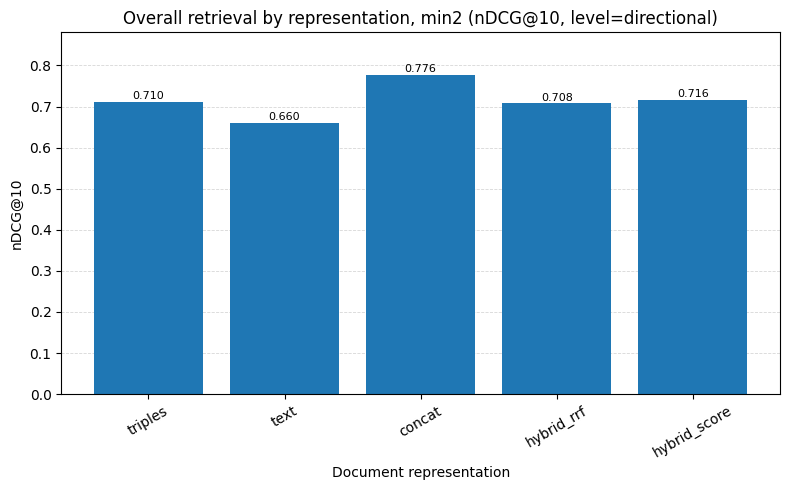

Saved: paper_plots/individual_min2_representation_nDCGat10_directional.png


In [4]:
overall_rep = representation_table_from_summary(
    SUMMARY_CSV,
    level=AGG_LEVEL,
)

display(overall_rep)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    overall_rep["representation_clean"].astype(str),
    overall_rep[METRIC],
)

ax.set_xlabel("Document representation")
ax.set_title(
    f"Overall retrieval by representation, {SELECTED_COMPLEXITY} "
    f"({METRIC}, level={AGG_LEVEL})"
)
ax.tick_params(axis="x", rotation=30)

style_metric_axis(ax, METRIC)
add_bar_labels(ax, fmt="{:.3f}", padding=0.002)

plt.tight_layout()

out_path = OUT_DIR / f"individual_{SELECTED_COMPLEXITY}_representation_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Plot 2 — Complexity comparison: min2 vs min3 vs min4

This is the corrected complexity comparison. It computes every complexity using the same `representation_table_from_summary` function used for the individual plot.

,representation_clean,n_queries,nDCG@10,complexity
0,triples,427392,0.710371,min2
1,text,284928,0.659680,min2
2,concat,534240,0.776477,min2
3,hybrid_rrf,427392,0.707667,min2
4,hybrid_score,427392,0.715771,min2
5,triples,397656,0.709033,min3
6,text,265104,0.654348,min3
7,concat,497070,0.774133,min3
8,hybrid_rrf,397656,0.704532,min3
9,hybrid_score,397656,0.711814,min3


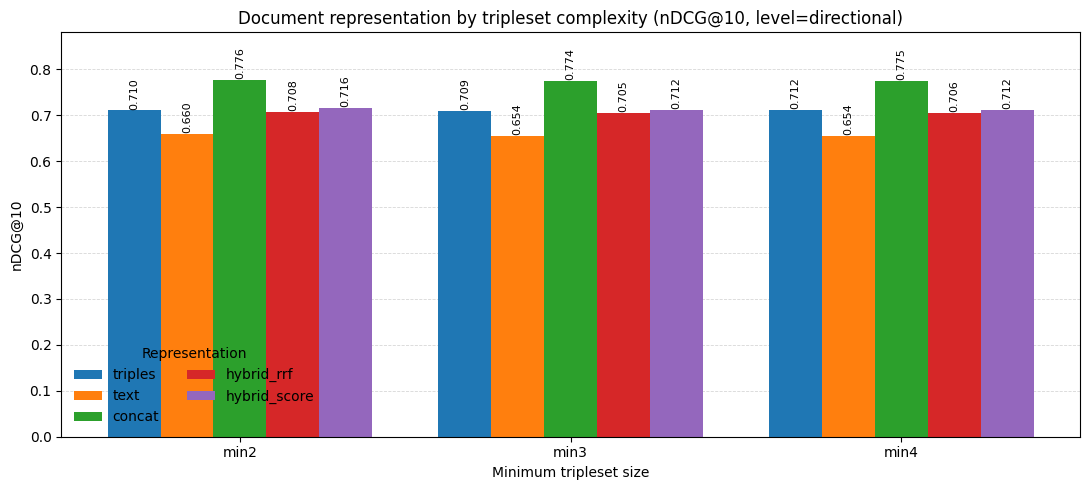

Saved: paper_plots/complexity_by_representation_nDCGat10_directional.png


In [5]:
complexity_tables = []

for complexity, path in SUMMARY_FILES.items():
    t = representation_table_from_summary(path, level=AGG_LEVEL)
    t["complexity"] = complexity
    complexity_tables.append(t)

rep_complexity = pd.concat(complexity_tables, ignore_index=True)

rep_complexity["complexity"] = pd.Categorical(
    rep_complexity["complexity"],
    categories=COMPLEXITY_ORDER,
    ordered=True,
)

rep_complexity["representation_clean"] = pd.Categorical(
    rep_complexity["representation_clean"],
    categories=REP_ORDER,
    ordered=True,
)

rep_complexity = rep_complexity.sort_values(
    ["complexity", "representation_clean"]
).reset_index(drop=True)

display(rep_complexity)

pivot = rep_complexity.pivot(
    index="complexity",
    columns="representation_clean",
    values=METRIC,
).reindex(COMPLEXITY_ORDER)

pivot = pivot[[c for c in REP_ORDER if c in pivot.columns]]

x = np.arange(len(pivot.index))
width = 0.8 / max(len(pivot.columns), 1)

fig, ax = plt.subplots(figsize=(11, 5))

for i, col in enumerate(pivot.columns):
    ax.bar(
        x + i * width - (len(pivot.columns) - 1) * width / 2,
        pivot[col].values,
        width,
        label=col,
    )

ax.set_xlabel("Minimum tripleset size")
ax.set_title(
    f"Document representation by tripleset complexity "
    f"({METRIC}, level={AGG_LEVEL})"
)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title="Representation", frameon=False, ncol=2)

style_metric_axis(ax, METRIC)
add_bar_labels(ax, fmt="{:.3f}", padding=0.002, fontsize=8, rotation=90)

plt.tight_layout()

out_path = OUT_DIR / f"complexity_by_representation_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Verification — individual result equals comparison result

This cell verifies that the individual plot for `SELECTED_COMPLEXITY` and the same complexity row in the comparison table are identical.

In [6]:
individual_selected = representation_table_from_summary(
    SUMMARY_FILES[SELECTED_COMPLEXITY],
    level=AGG_LEVEL,
)

comparison_selected = (
    rep_complexity[rep_complexity["complexity"].astype(str) == SELECTED_COMPLEXITY]
    [["representation_clean", METRIC]]
    .copy()
    .reset_index(drop=True)
)

check = individual_selected[["representation_clean", METRIC]].merge(
    comparison_selected,
    on="representation_clean",
    how="outer",
    suffixes=("_individual", "_comparison"),
)

check["abs_diff"] = (
    check[f"{METRIC}_individual"] - check[f"{METRIC}_comparison"]
).abs()

display(check)

max_diff = check["abs_diff"].max()
print(f"Max difference: {max_diff:.12f}")

assert max_diff < 1e-12, (
    "Individual and comparison results do not match. "
    "Check that AGG_LEVEL and source files are the same."
)


,representation_clean,nDCG@10_individual,nDCG@10_comparison,abs_diff
0,triples,0.710371,0.710371,0.0
1,text,0.659680,0.659680,0.0
2,concat,0.776477,0.776477,0.0
3,hybrid_rrf,0.707667,0.707667,0.0
4,hybrid_score,0.715771,0.715771,0.0


Max difference: 0.000000000000


## Plot 3 — Overall performance by complexity

,complexity,n_queries,nDCG@10
0,min2,2208192,0.719164
1,min3,2054556,0.715840
2,min4,1876368,0.716843


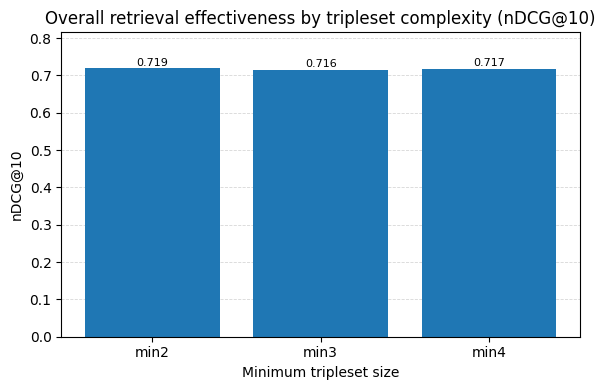

Saved: paper_plots/complexity_overall_nDCGat10_directional.png


In [7]:
df_complexity = load_all_complexities(SUMMARY_FILES)

main_complexity = []
for complexity, path in SUMMARY_FILES.items():
    d = read_summary_csv(path)
    selected = select_evaluation_level(
        d,
        split="ALL",
        question_type="ALL",
        level=AGG_LEVEL,
    )
    selected["complexity"] = complexity
    main_complexity.append(selected)

main_complexity = pd.concat(main_complexity, ignore_index=True)
main_complexity["representation_clean"] = main_complexity["representation"].apply(normalize_representation)

overall_complexity = aggregate(
    main_complexity,
    group_cols=["complexity"],
    metric=METRIC,
)

overall_complexity["complexity"] = pd.Categorical(
    overall_complexity["complexity"],
    categories=COMPLEXITY_ORDER,
    ordered=True,
)

overall_complexity = overall_complexity.sort_values("complexity")

display(overall_complexity)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    overall_complexity["complexity"].astype(str),
    overall_complexity[METRIC],
)

ax.set_xlabel("Minimum tripleset size")
ax.set_title(f"Overall retrieval effectiveness by tripleset complexity ({METRIC})")

style_metric_axis(ax, METRIC)
add_bar_labels(ax, fmt="{:.3f}", padding=0.002)

plt.tight_layout()

out_path = OUT_DIR / f"complexity_overall_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Plot 4 — Language direction by representation for the selected complexity

,direction,representation_clean,n_queries,nDCG@10
22,en→en,triples,47488,0.752444
21,en→en,text,47488,0.699927
17,en→en,concat,59360,0.814056
18,en→en,hybrid_rrf,47488,0.750346
19,en→en,hybrid_score,47488,0.756793
20,en→en,NaN,11872,0.708542
28,en→es,triples,47488,0.669007
27,en→es,text,47488,0.634034
23,en→es,concat,59360,0.739671
24,en→es,hybrid_rrf,47488,0.672052


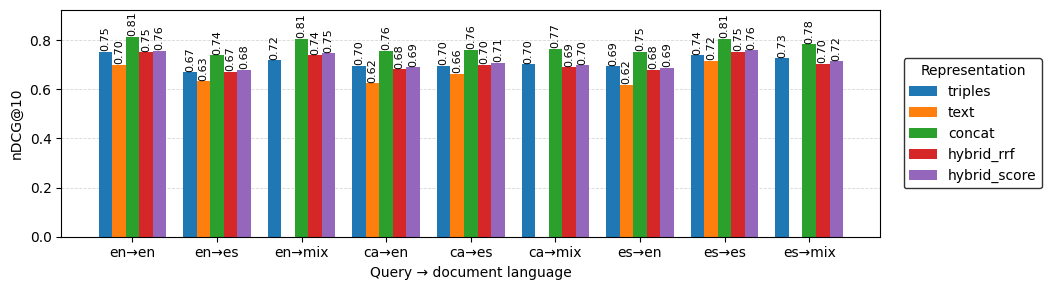

Saved: paper_plots/min2_representation_by_language_direction_nDCGat10.png


In [18]:
selected_directional = select_evaluation_level(
    df_single,
    split="ALL",
    question_type="ALL",
    level="directional",
)
selected_directional["representation_clean"] = selected_directional["representation"].apply(normalize_representation)
selected_directional["direction"] = selected_directional["query_lang"] + "→" + selected_directional["doc_lang"]

lang_rep = aggregate(
    selected_directional,
    group_cols=["direction", "representation_clean"],
    metric=METRIC,
)

lang_rep["direction"] = pd.Categorical(
    lang_rep["direction"],
    categories=DIRECTION_ORDER,
    ordered=True,
)

lang_rep["representation_clean"] = pd.Categorical(
    lang_rep["representation_clean"],
    categories=REP_ORDER,
    ordered=True,
)

lang_rep = lang_rep.sort_values(["direction", "representation_clean"])

display(lang_rep)

pivot = lang_rep.pivot(
    index="direction",
    columns="representation_clean",
    values=METRIC,
).reindex(DIRECTION_ORDER)

pivot = pivot[[c for c in REP_ORDER if c in pivot.columns]]

x = np.arange(len(pivot.index))
width = 0.8 / max(len(pivot.columns), 1)

fig, ax = plt.subplots(figsize=(13, 3))

for i, col in enumerate(pivot.columns):
    ax.bar(
        x + i * width - (len(pivot.columns) - 1) * width / 2,
        pivot[col].values,
        width,
        label=col,
    )

ax.set_xlabel("Query → document language")
#ax.set_title(f"Document representation by language direction, {SELECTED_COMPLEXITY} ({METRIC})")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(
    title="Representation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=True,
    edgecolor="black",
    ncol=1,
)



style_metric_axis(ax, METRIC)
add_bar_labels(ax, fmt="{:.2f}", padding=0.002, fontsize=8, rotation=90)

plt.tight_layout(rect=[0, 0, 0.82, 1])

out_path = OUT_DIR / f"{SELECTED_COMPLEXITY}_representation_by_language_direction_{METRIC.replace('@', 'at')}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Plot 5 — Method × representation heatmap for the selected complexity

representation_clean,triples,text,concat,hybrid_rrf,hybrid_score
method,,,,,
BGE_Dense,0.717555,0.676696,0.797360,0.719485,0.729258
BGE_MV,0.747826,0.710606,0.807110,0.749716,0.752890
BM25,0.611789,0.536220,0.643208,0.598638,0.608181
MILCO,0.764314,0.715199,0.827596,0.762829,0.772753


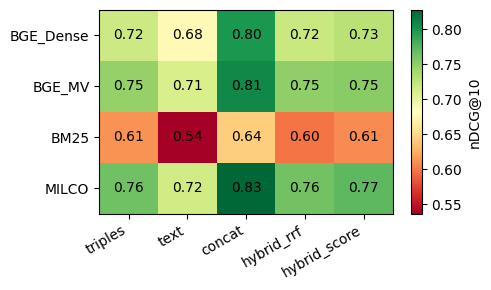

Saved: paper_plots/min2_method_by_representation_heatmap_nDCGat10.png


In [9]:
method_rep = aggregate(
    selected_directional,
    group_cols=["method", "representation_clean"],
    metric=METRIC,
)

method_order = sorted(method_rep["method"].dropna().unique())
rep_order_present = [r for r in REP_ORDER if r in set(method_rep["representation_clean"])]

heat = (
    method_rep
    .pivot(index="method", columns="representation_clean", values=METRIC)
    .reindex(index=method_order, columns=rep_order_present)
)

heat = heat.dropna(axis=0, how="all").dropna(axis=1, how="all")

display(heat)

fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(heat.values, aspect="auto", cmap = "RdYlGn")

plt.colorbar(im, ax=ax, label=METRIC)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

#ax.set_title(f"Retrieval method × document representation, {SELECTED_COMPLEXITY} ({METRIC})")
plt.tight_layout()

out_path = OUT_DIR / f"{SELECTED_COMPLEXITY}_method_by_representation_heatmap_{METRIC.replace('@', 'at')}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Plot 6 — Question type breakdown for the selected complexity

,question_type,representation_clean,n_queries,nDCG@10
17,yes,triples,108864,0.845296
16,yes,text,72576,0.802075
12,yes,concat,136080,0.897253
13,yes,hybrid_rrf,108864,0.844778
14,yes,hybrid_score,108864,0.851709
15,yes,NaN,27216,0.811744
11,no,triples,109116,0.720215
10,no,text,72744,0.676618
6,no,concat,136395,0.785999
7,no,hybrid_rrf,109116,0.720847


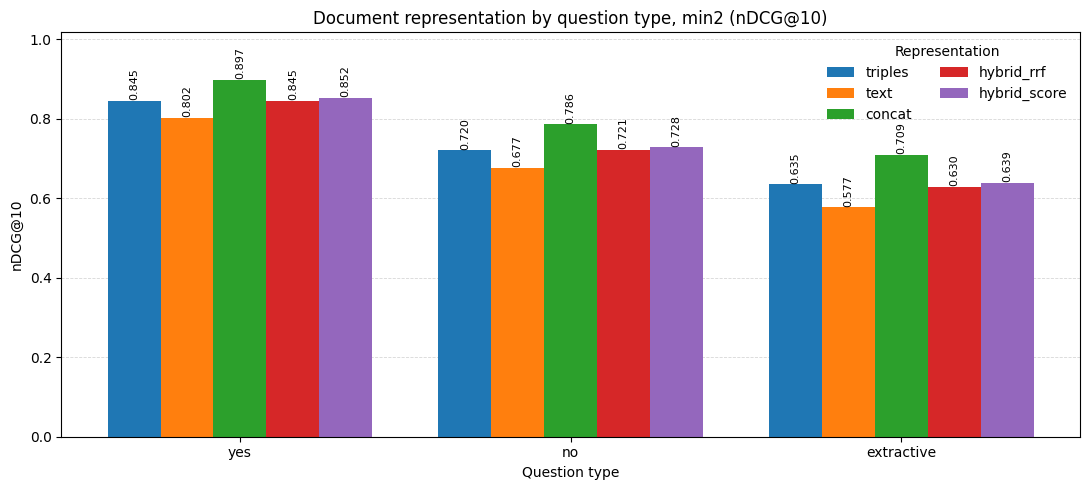

Saved: paper_plots/min2_representation_by_question_type_nDCGat10.png


In [10]:
qtype_df = select_evaluation_level(
    df_single,
    split="ALL",
    question_type=None,
    level="directional",
)
qtype_df["representation_clean"] = qtype_df["representation"].apply(normalize_representation)

# Remove aggregate ALL question-type rows.
qtype_df = qtype_df[
    ~qtype_df["question_type"].str.lower().isin(["all", "overall", "total"])
].copy()

q_order = order_existing(qtype_df["question_type"], QUESTION_ORDER)

qtype_rep = aggregate(
    qtype_df,
    group_cols=["question_type", "representation_clean"],
    metric=METRIC,
)

qtype_rep["question_type"] = pd.Categorical(
    qtype_rep["question_type"],
    categories=q_order,
    ordered=True,
)

qtype_rep["representation_clean"] = pd.Categorical(
    qtype_rep["representation_clean"],
    categories=REP_ORDER,
    ordered=True,
)

qtype_rep = qtype_rep.sort_values(["question_type", "representation_clean"])

display(qtype_rep)

pivot = qtype_rep.pivot(
    index="question_type",
    columns="representation_clean",
    values=METRIC,
).reindex(q_order)

pivot = pivot[[c for c in REP_ORDER if c in pivot.columns]]

x = np.arange(len(pivot.index))
width = 0.8 / max(len(pivot.columns), 1)

fig, ax = plt.subplots(figsize=(11, 5))

for i, col in enumerate(pivot.columns):
    ax.bar(
        x + i * width - (len(pivot.columns) - 1) * width / 2,
        pivot[col].values,
        width,
        label=col,
    )

ax.set_xlabel("Question type")
ax.set_title(f"Document representation by question type, {SELECTED_COMPLEXITY} ({METRIC})")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title="Representation", frameon=False, ncol=2)

style_metric_axis(ax, METRIC)
add_bar_labels(ax, fmt="{:.3f}", padding=0.002, fontsize=8, rotation=90)

plt.tight_layout()

out_path = OUT_DIR / f"{SELECTED_COMPLEXITY}_representation_by_question_type_{METRIC.replace('@', 'at')}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


## Plot 7 — Hybrid gain over best single representation

,hybrid,mean_gain
0,concat,0.058447
2,hybrid_score,0.005400
1,hybrid_rrf,-0.002704
3,hybrid_union_candidates,-0.031591


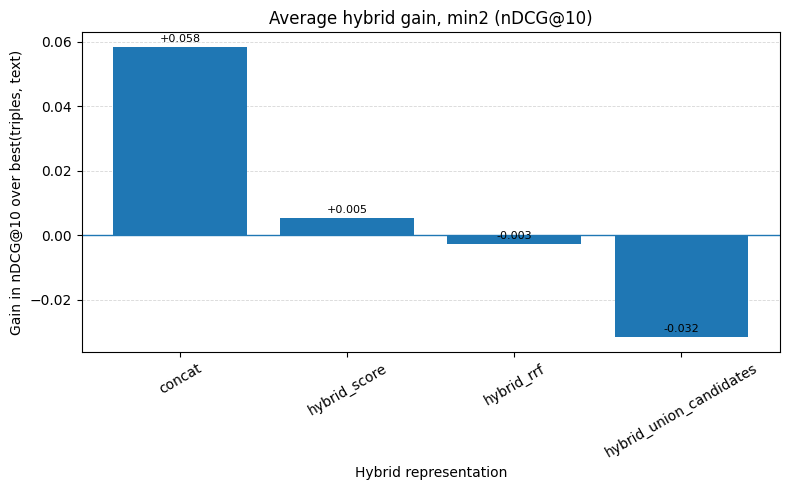

Saved: paper_plots/min2_hybrid_gain_nDCGat10.png


In [11]:
gain_df = selected_directional.copy()

valid_for_gain = {
    "triples", "text", "concat",
    "hybrid_rrf", "hybrid_score", "hybrid_union_candidates", "hybrid_cascade"
}
gain_df = gain_df[gain_df["representation_clean"].isin(valid_for_gain)].copy()
gain_df["direction"] = gain_df["query_lang"] + "→" + gain_df["doc_lang"]

base = aggregate(
    gain_df,
    group_cols=["method", "direction", "representation_clean"],
    metric=METRIC,
)

wide = base.pivot_table(
    index=["method", "direction"],
    columns="representation_clean",
    values=METRIC,
    aggfunc="mean",
).reset_index()

single_cols = [c for c in ["triples", "text"] if c in wide.columns]
hybrid_cols = [c for c in ["concat", "hybrid_rrf", "hybrid_score", "hybrid_union_candidates", "hybrid_cascade"] if c in wide.columns]

if len(single_cols) < 2:
    print("Need both triples and text columns to compute hybrid gain.")
elif not hybrid_cols:
    print("No hybrid columns found.")
else:
    wide["best_single"] = wide[single_cols].max(axis=1)

    rows = []
    for h in hybrid_cols:
        tmp = wide[["method", "direction", "best_single", h]].copy()
        tmp = tmp.rename(columns={h: "hybrid_score_value"})
        tmp["hybrid"] = h
        tmp["gain"] = tmp["hybrid_score_value"] - tmp["best_single"]
        rows.append(tmp)

    gains = pd.concat(rows, ignore_index=True)

    gains_agg = (
        gains
        .groupby("hybrid", as_index=False)
        .agg(mean_gain=("gain", "mean"))
        .sort_values("mean_gain", ascending=False)
    )

    display(gains_agg)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(gains_agg["hybrid"], gains_agg["mean_gain"])
    ax.axhline(0, linewidth=1)
    ax.set_ylabel(f"Gain in {METRIC} over best(triples, text)")
    ax.set_xlabel("Hybrid representation")
    ax.set_title(f"Average hybrid gain, {SELECTED_COMPLEXITY} ({METRIC})")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)
    add_bar_labels(ax, fmt="{:+.3f}", padding=0.001, fontsize=8)

    plt.tight_layout()

    out_path = OUT_DIR / f"{SELECTED_COMPLEXITY}_hybrid_gain_{METRIC.replace('@', 'at')}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


## Compact paper tables

In [12]:
# Table A: overall representation results for selected complexity.
table_rep = representation_table_from_summary(
    SUMMARY_CSV,
    level=AGG_LEVEL,
).sort_values(METRIC, ascending=False)

display(table_rep)
table_rep.to_csv(
    OUT_DIR / f"table_{SELECTED_COMPLEXITY}_overall_representation_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.csv",
    index=False,
)

# Table B: method × representation.
table_method_rep = aggregate(
    selected_directional,
    group_cols=["method", "representation_clean"],
    metric=METRIC,
).sort_values(["method", METRIC], ascending=[True, False])

display(table_method_rep)
table_method_rep.to_csv(
    OUT_DIR / f"table_{SELECTED_COMPLEXITY}_method_representation_{METRIC.replace('@', 'at')}.csv",
    index=False,
)

# Table C: direction × representation.
table_direction_rep = aggregate(
    selected_directional.assign(direction=selected_directional["query_lang"] + "→" + selected_directional["doc_lang"]),
    group_cols=["direction", "representation_clean"],
    metric=METRIC,
).sort_values(["direction", METRIC], ascending=[True, False])

display(table_direction_rep)
table_direction_rep.to_csv(
    OUT_DIR / f"table_{SELECTED_COMPLEXITY}_direction_representation_{METRIC.replace('@', 'at')}.csv",
    index=False,
)

# Table D: complexity × representation.
complexity_table = rep_complexity.sort_values(
    ["complexity", METRIC],
    ascending=[True, False],
)

display(complexity_table)
complexity_table.to_csv(
    OUT_DIR / f"table_complexity_by_representation_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.csv",
    index=False,
)

print("Saved compact tables to:", OUT_DIR)


,representation_clean,n_queries,nDCG@10
2,concat,534240,0.776477
4,hybrid_score,427392,0.715771
0,triples,427392,0.710371
3,hybrid_rrf,427392,0.707667
1,text,284928,0.659680


,method,representation_clean,n_queries,nDCG@10
0,BGE_Dense,concat,106848,0.797360
2,BGE_Dense,hybrid_score,106848,0.729258
1,BGE_Dense,hybrid_rrf,106848,0.719485
5,BGE_Dense,triples,106848,0.717555
3,BGE_Dense,hybrid_union_candidates,106848,0.685964
4,BGE_Dense,text,71232,0.676696
6,BGE_MV,concat,213696,0.807110
8,BGE_MV,hybrid_score,106848,0.752890
7,BGE_MV,hybrid_rrf,106848,0.749716
10,BGE_MV,triples,106848,0.747826


,direction,representation_clean,n_queries,nDCG@10
0,ca→en,concat,59360,0.756812
5,ca→en,triples,47488,0.695339
2,ca→en,hybrid_score,47488,0.689104
3,ca→en,hybrid_union_candidates,11872,0.687429
1,ca→en,hybrid_rrf,47488,0.681914
4,ca→en,text,47488,0.624698
6,ca→es,concat,59360,0.761883
8,ca→es,hybrid_score,47488,0.708376
7,ca→es,hybrid_rrf,47488,0.700842
11,ca→es,triples,47488,0.695182


,representation_clean,n_queries,nDCG@10,complexity
2,concat,534240,0.776477,min2
4,hybrid_score,427392,0.715771,min2
0,triples,427392,0.710371,min2
3,hybrid_rrf,427392,0.707667,min2
1,text,284928,0.659680,min2
7,concat,497070,0.774133,min3
9,hybrid_score,397656,0.711814,min3
5,triples,397656,0.709033,min3
8,hybrid_rrf,397656,0.704532,min3
6,text,265104,0.654348,min3


Saved compact tables to: paper_plots


## Diagnostic: compare `directional` vs `overall` aggregation

Use this only to understand differences. The plots above deliberately use a single level to avoid mixing aggregation modes.

In [13]:
try:
    directional_table = representation_table_from_summary(SUMMARY_CSV, level="directional")
    overall_table = representation_table_from_summary(SUMMARY_CSV, level="overall")

    diag = directional_table[["representation_clean", METRIC]].merge(
        overall_table[["representation_clean", METRIC]],
        on="representation_clean",
        how="outer",
        suffixes=("_directional", "_overall"),
    )
    diag["diff_directional_minus_overall"] = diag[f"{METRIC}_directional"] - diag[f"{METRIC}_overall"]

    display(diag)
except Exception as e:
    print("Could not compute directional vs overall diagnostic:")
    print(e)


,representation_clean,nDCG@10_directional,nDCG@10_overall,diff_directional_minus_overall
0,triples,0.710371,0.710371,0.000000e+00
1,text,0.659680,0.659680,0.000000e+00
2,concat,0.776477,0.776477,0.000000e+00
3,hybrid_rrf,0.707667,0.707667,0.000000e+00
4,hybrid_score,0.715771,0.715771,-1.110223e-16



min2: representation × retrieval method (nDCG@10, level=directional)


,method,representation_clean,n_queries,nDCG@10,complexity
0,bm25,triples,106848,0.611789,min2
1,bm25,text,71232,0.536220,min2
2,bm25,concat,106848,0.643208,min2
3,bm25,hybrid_rrf,106848,0.598638,min2
4,bm25,hybrid_score,106848,0.608181,min2
5,bge_m3_dense,triples,106848,0.717555,min2
6,bge_m3_dense,text,71232,0.676696,min2
7,bge_m3_dense,concat,106848,0.797360,min2
8,bge_m3_dense,hybrid_rrf,106848,0.719485,min2
9,bge_m3_dense,hybrid_score,106848,0.729258,min2


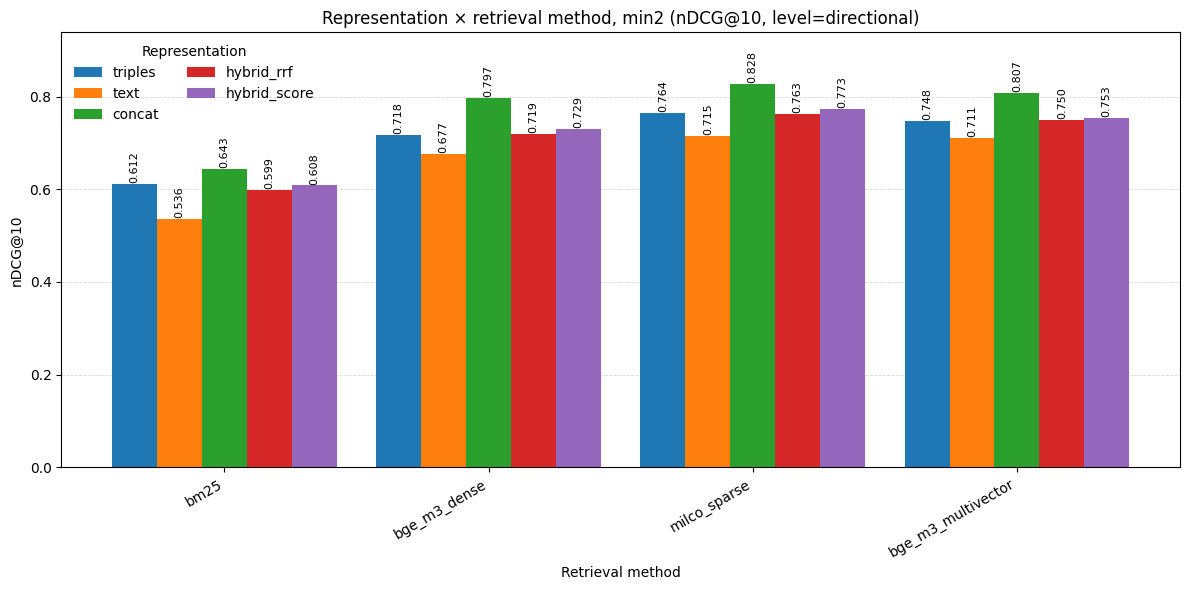

Saved: paper_plots/min2_method_by_representation_nDCGat10_directional.png

min3: representation × retrieval method (nDCG@10, level=directional)


,method,representation_clean,n_queries,nDCG@10,complexity
0,bm25,triples,99414,0.616326,min3
1,bm25,text,66276,0.532514,min3
2,bm25,concat,99414,0.645129,min3
3,bm25,hybrid_rrf,99414,0.598979,min3
4,bm25,hybrid_score,99414,0.608344,min3
5,bge_m3_dense,triples,99414,0.710704,min3
6,bge_m3_dense,text,66276,0.664360,min3
7,bge_m3_dense,concat,99414,0.793923,min3
8,bge_m3_dense,hybrid_rrf,99414,0.710284,min3
9,bge_m3_dense,hybrid_score,99414,0.719545,min3


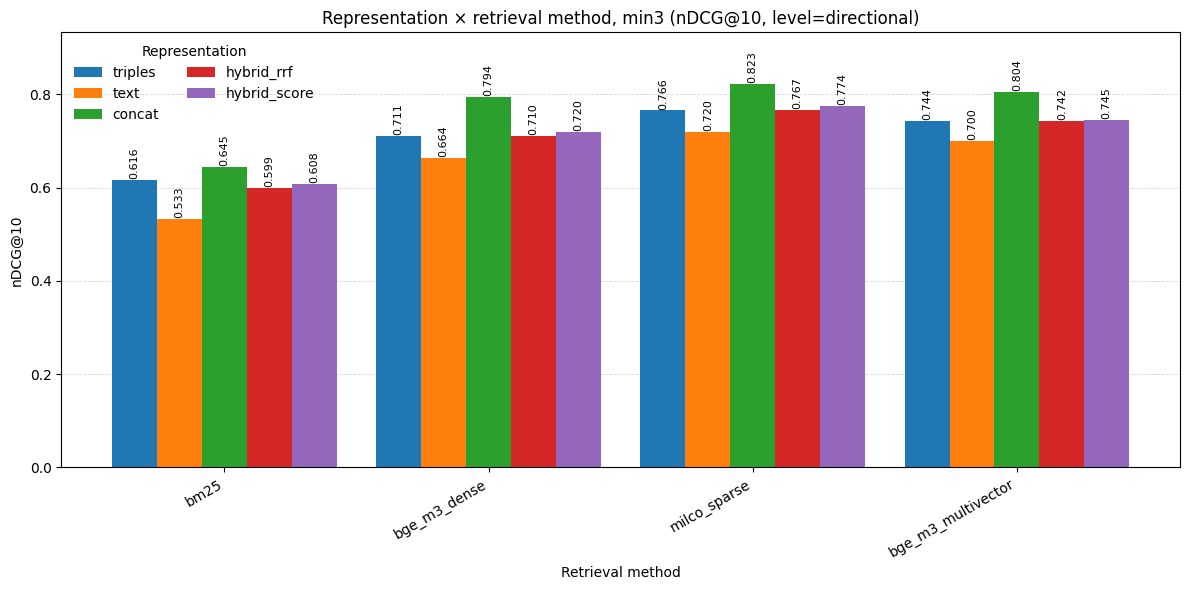

Saved: paper_plots/min3_method_by_representation_nDCGat10_directional.png

min4: representation × retrieval method (nDCG@10, level=directional)


,method,representation_clean,n_queries,nDCG@10,complexity
0,bm25,triples,90792,0.620360,min4
1,bm25,text,60528,0.531682,min4
2,bm25,concat,90792,0.647881,min4
3,bm25,hybrid_rrf,90792,0.600921,min4
4,bm25,hybrid_score,90792,0.610155,min4
5,bge_m3_dense,triples,90792,0.710611,min4
6,bge_m3_dense,text,60528,0.658986,min4
7,bge_m3_dense,concat,90792,0.794322,min4
8,bge_m3_dense,hybrid_rrf,90792,0.707538,min4
9,bge_m3_dense,hybrid_score,90792,0.716446,min4


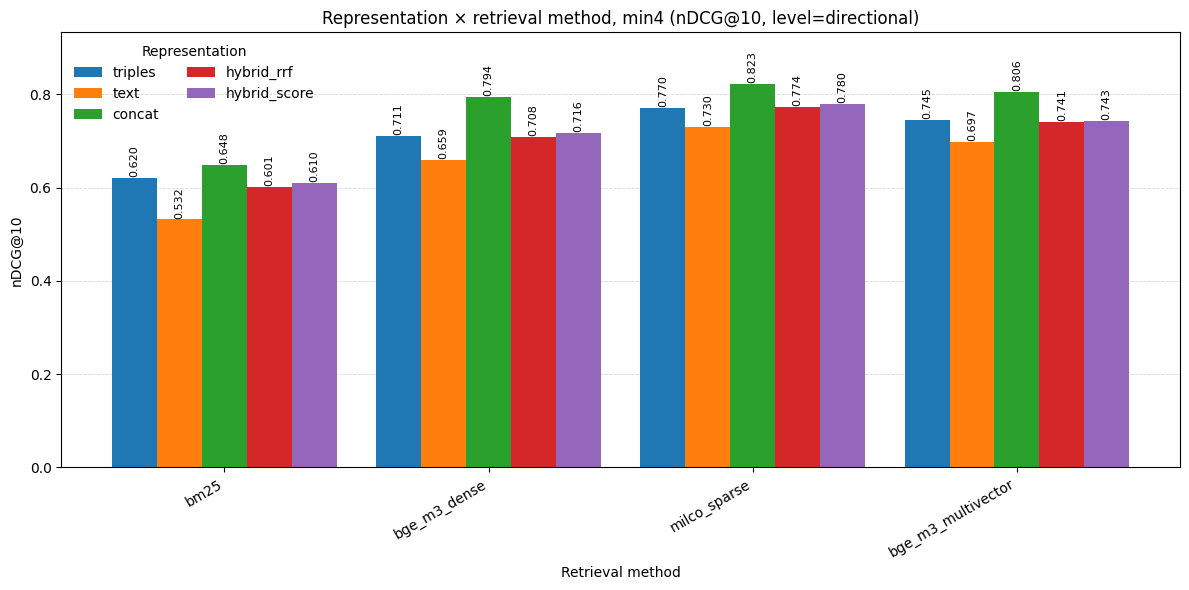

Saved: paper_plots/min4_method_by_representation_nDCGat10_directional.png


,method,representation_clean,n_queries,nDCG@10,complexity
0,bm25,triples,106848,0.611789,min2
1,bm25,text,71232,0.536220,min2
2,bm25,concat,106848,0.643208,min2
3,bm25,hybrid_rrf,106848,0.598638,min2
4,bm25,hybrid_score,106848,0.608181,min2
5,bge_m3_dense,triples,106848,0.717555,min2
6,bge_m3_dense,text,71232,0.676696,min2
7,bge_m3_dense,concat,106848,0.797360,min2
8,bge_m3_dense,hybrid_rrf,106848,0.719485,min2
9,bge_m3_dense,hybrid_score,106848,0.729258,min2


Saved table: paper_plots/table_method_by_representation_by_complexity_nDCGat10_directional.csv


In [14]:
# ============================================================
# Plot: representation × retrieval method for each min setting
# ============================================================

# Expected to already exist from previous cells:
#   SUMMARY_FILES
#   OUT_DIR
#   METRIC
#   REP_ORDER
#   COMPLEXITY_ORDER
#   read_summary_csv
#   select_evaluation_level
#   aggregate
#   add_bar_labels
#   style_metric_axis

AGG_LEVEL = "directional"   # use "directional" or "overall"; keep consistent with previous plots

METHOD_ORDER = [
    "bm25",
    "bge_m3_dense",
    "bge_dense",
    "dense_bge",
    "milco_sparse",
    "sparse_milco",
    "bge_m3_multivector",
    "multivector",
]

REPRESENTATIONS_TO_PLOT = [
    "triples",
    "text",
    "concat",
    "hybrid_rrf",
    "hybrid_score",
    #"hybrid_union_candidates",
    #"hybrid_cascade",
]


def order_existing(values, preferred_order):
    values = list(pd.Series(values).dropna().astype(str).unique())
    preferred_present = [x for x in preferred_order if x in values]
    remaining = sorted([x for x in values if x not in preferred_present])
    return preferred_present + remaining


def method_representation_table_from_summary(path, level="directional"):
    df = read_summary_csv(path)

    selected = select_evaluation_level(
        df,
        split="ALL",
        question_type="ALL",
        level=level,
    )

    # Keep only desired representation families.
    selected = selected[
        selected["representation_clean"].isin(REPRESENTATIONS_TO_PLOT)
    ].copy()

    table = aggregate(
        selected,
        group_cols=["method", "representation_clean"],
        metric=METRIC,
    )

    method_order = order_existing(table["method"], METHOD_ORDER)
    rep_order = order_existing(table["representation_clean"], REPRESENTATIONS_TO_PLOT)

    table["method"] = pd.Categorical(
        table["method"],
        categories=method_order,
        ordered=True,
    )

    table["representation_clean"] = pd.Categorical(
        table["representation_clean"],
        categories=rep_order,
        ordered=True,
    )

    table = table.sort_values(["method", "representation_clean"]).reset_index(drop=True)

    return table, method_order, rep_order


# -------------------------
# One plot per min
# -------------------------

all_method_rep_tables = []

for complexity, path in SUMMARY_FILES.items():
    method_rep, method_order, rep_order = method_representation_table_from_summary(
        path,
        level=AGG_LEVEL,
    )

    method_rep["complexity"] = complexity
    all_method_rep_tables.append(method_rep)

    print("\n" + "=" * 100)
    print(f"{complexity}: representation × retrieval method ({METRIC}, level={AGG_LEVEL})")
    print("=" * 100)
    display(method_rep)

    pivot = method_rep.pivot(
        index="method",
        columns="representation_clean",
        values=METRIC,
    ).reindex(method_order)

    pivot = pivot[[c for c in rep_order if c in pivot.columns]]

    x = np.arange(len(pivot.index))
    width = 0.85 / max(len(pivot.columns), 1)

    fig, ax = plt.subplots(figsize=(max(12, 1.6 * len(pivot.index)), 6))

    for i, col in enumerate(pivot.columns):
        ax.bar(
            x + i * width - (len(pivot.columns) - 1) * width / 2,
            pivot[col].values,
            width,
            label=col,
        )

    ax.set_xlabel("Retrieval method")
    ax.set_title(
        f"Representation × retrieval method, {complexity} "
        f"({METRIC}, level={AGG_LEVEL})"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=30, ha="right")
    ax.legend(title="Representation", frameon=False, ncol=2)

    style_metric_axis(ax, METRIC)
    add_bar_labels(ax, fmt="{:.3f}", padding=0.002, fontsize=8, rotation=90)

    plt.tight_layout()

    out_path = OUT_DIR / (
        f"{complexity}_method_by_representation_"
        f"{METRIC.replace('@', 'at')}_{AGG_LEVEL}.png"
    )
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# -------------------------
# Combined table for export
# -------------------------

method_rep_all = pd.concat(all_method_rep_tables, ignore_index=True)

method_rep_all["complexity"] = pd.Categorical(
    method_rep_all["complexity"],
    categories=COMPLEXITY_ORDER,
    ordered=True,
)

method_rep_all = method_rep_all.sort_values(
    ["complexity", "method", "representation_clean"]
).reset_index(drop=True)

display(method_rep_all)

out_path = OUT_DIR / f"table_method_by_representation_by_complexity_{METRIC.replace('@', 'at')}_{AGG_LEVEL}.csv"
method_rep_all.to_csv(out_path, index=False)

print("Saved table:", out_path)